In [21]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [22]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [23]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [24]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2499


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""",null,null,null,null,null,null,false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5"""
"""23/07/2025""","""1214""","""22 13 24 43 02 01""","""21""","""49""","""Promoción Sí o Sí""","""010213222443""","[1, 2, … 43]",1,2,13,22,24,43,"""01""","""02""","""13""","""22""","""24""","""43""","""04""","""09""","""21""","""24""","""34""","""36""",false,0,"""01_11_09_02_19""",22,"""3""","""3""","""3""","""1""","""11""","""9""","""2""","""19""","""42""","""2""","""5"""
"""20/07/2025""","""1213""","""42 45 28 06 19 05""","""10""","""37""","""Promoción Sí o Sí""","""050619284245""","[5, 6, … 45]",5,6,19,28,42,45,"""05""","""06""","""19""","""28""","""42""","""45""","""01""","""02""","""13""","""22""","""24""","""43""",true,16,"""01_13_09_14_03""",-50,"""2""","""3""","""3""","""1""","""13""","""9""","""14""","""3""","""40""","""2""","""5"""
"""16/07/2025""","""1212""","""36 22 37 11 07 01""","""24""","""19""","""Promoción Sí o Sí""","""010711223637""","[1, 7, … 37]",1,7,11,22,36,37,"""01""","""07""","""11""","""22""","""36""","""37""","""05""","""06""","""19""","""28""","""42""","""45""",false,0,"""06_04_11_14_01""",1,"""3""","""2""","""4""","""6""","""4""","""11""","""14""","""1""","""36""","""2""","""5"""
"""13/07/2025""","""1211""","""09 32 43 49 38 24""","""05""","""35 30""","""Promoción Sí o Sí""","""092432384349""","[9, 24, … 49]",9,24,32,38,43,49,"""09""","""24""","""32""","""38""","""43""","""49""","""01""","""07""","""11""","""22""","""36""","""37""",true,16,"""15_08_06_05_06""",5,"""1""","""3""","""3""","""15""","""8""","""6""","""5""","""6""","""40""","""1""","""4"""
"""09/07/2025""","""1210""","""35 28 09 42 31 16""","""45""","""50 23""","""Promoción Sí o Sí""","""091628313542""","[9, 16, … 42]",9,16,28,31,35,42,"""09""","""16""","""28""","""31""","""35""","""42""","""09""","""24""","""32""","""38""","""43""","""49""",false,0,"""07_12_03_04_07""",-32,"""1""","""3""","""3""","""7""","""12""","""3""","""4""","""7""","""33""","""1""","""4"""
"""06/07/2025""","""1209""","""29 20 14 11 03 15""","""35""","""12 33 37""","""Promoción Sí o Sí""","""031114152029""","[3, 11, … 29]",3,11,14,15,20,29,"""03""","""11""","""14""","""15""","""20""","""29""","""09""","""16""","""28""","""31""","""35""","""42""",false,0,"""08_03_01_05_09""",-9,"""3""","""2""","""4""","""8""","""3""","""1""","""5""","""9""","""26""","""0""","""5"""


In [47]:
dfRows[0:20]

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""",null,null,null,null,null,null,false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5"""
"""23/07/2025""","""1214""","""22 13 24 43 02 01""","""21""","""49""","""Promoción Sí o Sí""","""010213222443""","[1, 2, … 43]",1,2,13,22,24,43,"""01""","""02""","""13""","""22""","""24""","""43""","""04""","""09""","""21""","""24""","""34""","""36""",false,0,"""01_11_09_02_19""",22,"""3""","""3""","""3""","""1""","""11""","""9""","""2""","""19""","""42""","""2""","""5"""
"""20/07/2025""","""1213""","""42 45 28 06 19 05""","""10""","""37""","""Promoción Sí o Sí""","""050619284245""","[5, 6, … 45]",5,6,19,28,42,45,"""05""","""06""","""19""","""28""","""42""","""45""","""01""","""02""","""13""","""22""","""24""","""43""",true,16,"""01_13_09_14_03""",-50,"""2""","""3""","""3""","""1""","""13""","""9""","""14""","""3""","""40""","""2""","""5"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""11/06/2025""","""1202""","""22 39 20 19 38 15""","""32""","""13 35 25""","""Promoción Sí o Sí""","""151920223839""","[15, 19, … 39]",15,19,20,22,38,39,"""15""","""19""","""20""","""22""","""38""","""39""","""24""","""29""","""34""","""41""","""42""","""44""",false,0,"""04_01_02_16_01""",-51,"""1""","""3""","""3""","""4""","""1""","""2""","""16""","""1""","""24""","""1""","""4"""
"""08/06/2025""","""1201""","""05 08 25 18 34 12""","""14""","""44""","""Promoción Sí o Sí""","""050812182534""","[5, 8, … 34]",5,8,12,18,25,34,"""05""","""08""","""12""","""18""","""25""","""34""","""15""","""19""","""20""","""22""","""38""","""39""",false,0,"""03_04_06_07_09""",4,"""1""","""4""","""2""","""3""","""4""","""6""","""7""","""9""","""29""","""0""","""5"""
"""04/06/2025""","""1200""","""01 36 50 30 05 21""","""37""","""09 24 43""","""Promoción Sí o Sí""","""010521303650""","[1, 5, … 50]",1,5,21,30,36,50,"""01""","""05""","""21""","""30""","""36""","""50""","""05""","""08""","""12""","""18""","""25""","""34""",false,0,"""04_16_09_06_14""",-16,"""1""","""3""","""3""","""4""","""16""","""9""","""6""","""14""","""49""","""2""","""5"""


In [25]:

def count_column (col_name: str, k: int = None) -> None:
  df_viz = (dfRows if k == None else dfRows[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jdiff_count = count_column('jdiff', 100)

j1_count = count_column('j1', 100)
j2_count = count_column('j2', 100)
j3_count = count_column('j3', 100)
j4_count = count_column('j4', 100)
j5_count = count_column('j5', 100)

joor_count = count_column("joor", 100)
primes_count = count_column('primes_count', 100)
evens_count = count_column('evens_count', 100)
odds_count = count_column('odds_count', 100)

jsums = count_column('jsum', 100)
# print(jsums[0:22])



:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

:Bars   [j4]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [26]:
dfRows.item(0, 'b2')

14

In [27]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [28]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='02'
df_viz FOR str_b1 = 02


post_str_b1,count,percent
str,u32,f64
"""01""",43,14.098361
"""02""",35,11.47541
"""05""",28,9.180328
"""04""",28,9.180328
"""03""",24,7.868852
…,…,…
"""18""",1,0.327869
"""23""",1,0.327869
"""21""",1,0.327869


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 02
Last 3 results last_results=['02', '01', '08']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2""","""5"""
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4"""
"""28/05/2025""","""1198""","""02 16 15 50 09 04""","""37""","""30 25 49 13""","""Promoción Sí o Sí""","""020409151650""","[2, 4, … 50]",2,4,9,15,16,50,"""02""","""04""","""09""","""15""","""16""","""50""","""02""","""14""","""16""","""19""","""22""","""43""",true,16,"""02_05_06_01_34""",48,"""1""","""4""","""2""","""2""","""5""","""6""","""1""","""34""","""48""","""1""","""5"""
"""07/05/2025""","""1192""","""48 02 38 50 33 35""","""49""","""20 16""","""Promoción Sí o Sí""","""023335384850""","[2, 33, … 50]",2,33,35,38,48,50,"""02""","""33""","""35""","""38""","""48""","""50""","""03""","""21""","""43""","""45""","""46""","""49""",true,16,"""31_02_03_10_02""",3,"""1""","""4""","""2""","""31""","""2""","""3""","""10""","""2""","""48""","""2""","""4"""
"""30/04/2025""","""1190""","""11 36 33 06 02 16""","""37""","""14 07 10 01""","""Promoción Sí o Sí""","""020611163336""","[2, 6, … 36]",2,6,11,16,33,36,"""02""","""06""","""11""","""16""","""33""","""36""","""09""","""10""","""15""","""19""","""35""","""37""",true,8,"""04_05_05_17_03""",-51,"""2""","""4""","""2""","""4""","""5""","""5""","""17""","""3""","""34""","""1""","""4"""
"""20/04/2025""","""1187""","""33 02 06 42 34 11""","""37""","""49 20""","""Promoción Sí o Sí""","""020611333442""","[2, 6, … 42]",2,6,11,33,34,42,"""02""","""06""","""11""","""33""","""34""","""42""","""09""","""16""","""20""","""22""","""33""","""35""",false,0,"""04_05_22_01_08""",120,"""2""","""4""","""2""","""4""","""5""","""22""","""1""","""8""","""40""","""1""","""5"""
"""19/02/2025""","""1170""","""44 02 19 47 29 31""","""21""","""32 14 35""","""Promoción Sí o Sí""","""021929314447""","[2, 19, … 47]",2,19,29,31,44,47,"""02""","""19""","""29""","""31""","""44""","""47""","""05""","""08""","""10""","""30""","""36""","""44""",true,1,"""17_10_02_13_03""",-60,"""5""","""2""","""4""","""17""","""10""","""2""","""13""","""3""","""45""","""3""","""5"""
"""25/12/2024""","""1154""","""14 39 24 02 05 15""","""44""","""48 27 34 38""","""Promoción Sí o Sí""","""020514152439""","[2, 5, … 39]",2,5,14,15,24,39,"""02""","""05""","""14""","""15""","""24""","""39""","""29""","""35""","""41""","""42""","""49""","""50""",false,0,"""03_09_01_09_15""",-48,"""2""","""3""","""3""","""3""","""9""","""1""","""9""","""15""","""37""","""1""","""4"""
"""04/12/2024""","""1148""","""17 29 20 38 02 36""","""26""","""33 01 05""","""Promoción Sí o Sí""","""021720293638""","[2, 17, … 38]",2,17,20,29,36,38,"""02""","""17""","""20""","""29""","""36""","""38""","""08""","""17""","""26""","""43""","""44""","""45""",false,0,"""15_03_09_07_02""",31,"""3""","""4""","""2""","""15""","""3""","""9""","""7""","""2""","""36""","""1""","""5"""


df_jumps_map FOR str_b1 = 02


jumps_map,count
str,u32
"""04_02_01_05_11""",1
"""16_09_05_05_05""",1
"""16_02_06_03_04""",1
"""09_02_05_06_01""",1
"""01_08_11_03_15""",1
…,…
"""01_04_08_13_02""",1
"""07_08_14_01_09""",1
"""06_02_05_28_02""",1


df_unijump FOR str_b1 = 02


unijump,count
i64,u32
3,9
-11,6
15,5
-35,5
29,5
…,…
4,1
37,1
68,1


In [29]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='14'
df_viz FOR str_b2 = 14


post_str_b2,count,percent
str,u32,f64
"""08""",10,8.547009
"""13""",8,6.837607
"""14""",8,6.837607
"""06""",7,5.982906
"""11""",7,5.982906
…,…,…
"""29""",2,1.709402
"""30""",1,0.854701
"""24""",1,0.854701


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 14
Last 3 results last_results=['23', '06', '05']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""25/06/2025""","""1206""","""38 30 08 27 48 14""","""17""","""18""","""Promoción Sí o Sí""","""081427303848""","[8, 14, … 48]",8,14,27,30,38,48,"""08""","""14""","""27""","""30""","""38""","""48""","""22""","""23""","""24""","""32""","""37""","""47""",false,0,"""06_13_03_08_10""",-50,"""0""","""5""","""1""","""6""","""13""","""3""","""8""","""10""","""40""","""2""","""5"""
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4"""
"""16/04/2025""","""1186""","""14 31 46 38 48 12""","""15""","""39 30""","""Promoción Sí o Sí""","""121431384648""","[12, 14, … 48]",12,14,31,38,46,48,"""12""","""14""","""31""","""38""","""46""","""48""","""02""","""06""","""11""","""33""","""34""","""42""",false,0,"""02_17_07_08_02""",-54,"""1""","""5""","""1""","""2""","""17""","""7""","""8""","""2""","""36""","""1""","""4"""
"""08/09/2024""","""1123""","""15 35 14 07 18 23""","""50""","""33 46""","""Promoción Sí o Sí""","""071415182335""","[7, 14, … 35]",7,14,15,18,23,35,"""07""","""14""","""15""","""18""","""23""","""35""","""04""","""07""","""28""","""29""","""41""","""46""",false,0,"""07_01_03_05_12""",13,"""2""","""2""","""4""","""7""","""1""","""3""","""5""","""12""","""28""","""1""","""5"""
"""25/08/2024""","""1119""","""49 01 42 14 27 36""","""05""","""21 45""","""Promoción Sí o Sí""","""011427364249""","[1, 14, … 49]",1,14,27,36,42,49,"""01""","""14""","""27""","""36""","""42""","""49""","""03""","""06""","""11""","""37""","""46""","""47""",true,8,"""13_13_09_06_07""",-2,"""0""","""3""","""3""","""13""","""13""","""9""","""6""","""7""","""48""","""2""","""4"""
"""07/08/2024""","""1114""","""10 38 36 18 32 14""","""33""","""31 29 42 28""","""Promoción Sí o Sí""","""101418323638""","[10, 14, … 38]",10,14,18,32,36,38,"""10""","""14""","""18""","""32""","""36""","""38""","""12""","""18""","""38""","""43""","""47""","""50""",true,12,"""04_04_14_04_02""",58,"""0""","""6""","""0""","""4""","""4""","""14""","""4""","""2""","""28""","""1""","""3"""
"""05/06/2024""","""1096""","""21 24 09 14 22 33""","""08""","""48 07""","""Promoción Sí o Sí""","""091421222433""","[9, 14, … 33]",9,14,21,22,24,33,"""09""","""14""","""21""","""22""","""24""","""33""","""03""","""07""","""11""","""20""","""29""","""39""",false,0,"""05_07_01_02_09""",-16,"""0""","""3""","""3""","""5""","""7""","""1""","""2""","""9""","""24""","""0""","""5"""
"""31/03/2024""","""1077""","""17 29 43 27 04 14""","""06""","""25""","""Promoción Sí o Sí""","""041417272943""","[4, 14, … 43]",4,14,17,27,29,43,"""04""","""14""","""17""","""27""","""29""","""43""","""02""","""07""","""18""","""26""","""31""","""38""",false,0,"""10_03_10_02_14""",64,"""3""","""2""","""4""","""10""","""3""","""10""","""2""","""14""","""39""","""3""","""4"""
"""28/02/2024""","""1068""","""42 13 30 27 45 14""","""08""","""15 03""","""Promoción Sí o Sí""","""131427304245""","[13, 14, … 45]",13,14,27,30,42,45,"""13""","""14""","""27""","""30""","""42""","""45""","""06""","""25""","""27""","""31""","""33""","""48""",false,0,"""01_13_03_12_03""",-78,"""1""","""3""","""3""","""1""","""13""","""3""","""12""","""3""","""32""","""2""","""4"""


df_jumps_map FOR str_b2 = 14


jumps_map,count
str,u32
"""08_03_08_12_04""",1
"""05_09_06_13_03""",1
"""07_07_14_04_04""",1
"""03_03_02_17_07""",1
"""05_05_12_02_13""",1
…,…
"""09_01_15_14_01""",1
"""03_17_07_01_06""",1
"""10_06_10_11_04""",1


df_unijump FOR str_b2 = 14


unijump,count
i64,u32
4,4
-23,4
-16,3
7,3
-49,3
…,…
-45,1
8,1
-54,1


In [30]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='23'
df_viz FOR str_b3 = 23


post_str_b3,count,percent
str,u32,f64
"""19""",8,8.333333
"""22""",8,8.333333
"""21""",7,7.291667
"""26""",6,6.25
"""18""",5,5.208333
…,…,…
"""39""",1,1.041667
"""28""",1,1.041667
"""29""",1,1.041667


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 23
Last 3 results last_results=['17', '27']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""02/04/2025""","""1182""","""46 10 23 31 40 22""","""50""","""03 13 25""","""Promoción Sí o Sí""","""102223314046""","[10, 22, … 46]",10,22,23,31,40,46,"""10""","""22""","""23""","""31""","""40""","""46""","""05""","""16""","""27""","""34""","""42""","""49""",false,0,"""12_01_08_09_06""",26,"""2""","""4""","""2""","""12""","""1""","""8""","""9""","""6""","""36""","""1""","""5"""
"""09/03/2025""","""1175""","""01 42 44 20 38 23""","""14""","""35 36 34 45 41""","""Promoción Sí o Sí""","""012023384244""","[1, 20, … 44]",1,20,23,38,42,44,"""01""","""20""","""23""","""38""","""42""","""44""","""07""","""16""","""17""","""32""","""34""","""44""",false,0,"""19_03_15_04_02""",83,"""1""","""4""","""2""","""19""","""3""","""15""","""4""","""2""","""43""","""2""","""5"""
"""09/10/2024""","""1132""","""15 20 48 37 27 23""","""39""","""07 38 19""","""Promoción Sí o Sí""","""152023273748""","[15, 20, … 48]",15,20,23,27,37,48,"""15""","""20""","""23""","""27""","""37""","""48""","""05""","""09""","""17""","""21""","""28""","""31""",false,0,"""05_03_04_10_11""",-12,"""2""","""2""","""4""","""5""","""3""","""4""","""10""","""11""","""33""","""2""","""5"""
"""01/09/2024""","""1121""","""23 50 41 19 04 37""","""28""","""09 06""","""Promoción Sí o Sí""","""041923374150""","[4, 19, … 50]",4,19,23,37,41,50,"""04""","""19""","""23""","""37""","""41""","""50""","""04""","""09""","""15""","""30""","""40""","""50""",true,1,"""15_04_14_04_09""",76,"""4""","""2""","""4""","""15""","""4""","""14""","""4""","""9""","""46""","""2""","""4"""
"""31/12/2023""","""1051""","""35 28 15 23 27 09""","""14""","""45 32 40""","""Promoción Sí o Sí""","""091523272835""","[9, 15, … 35]",9,15,23,27,28,35,"""09""","""15""","""23""","""27""","""28""","""35""","""04""","""12""","""15""","""28""","""35""","""39""",false,0,"""06_08_04_01_07""",1,"""1""","""1""","""5""","""6""","""8""","""4""","""1""","""7""","""26""","""0""","""5"""
"""22/11/2023""","""1040""","""48 09 29 43 22 23""","""30""","""44 46 17 42""","""Promoción Sí o Sí""","""092223294348""","[9, 22, … 48]",9,22,23,29,43,48,"""09""","""22""","""23""","""29""","""43""","""48""","""08""","""24""","""33""","""40""","""41""","""45""",true,16,"""13_01_06_14_05""",-6,"""3""","""2""","""4""","""13""","""1""","""6""","""14""","""5""","""39""","""2""","""5"""
"""01/11/2023""","""1034""","""35 23 21 46 11 28""","""25""","""03 32""","""Promoción Sí o Sí""","""112123283546""","[11, 21, … 46]",11,21,23,28,35,46,"""11""","""21""","""23""","""28""","""35""","""46""","""03""","""14""","""19""","""25""","""32""","""34""",false,0,"""10_02_05_07_11""",15,"""2""","""2""","""4""","""10""","""2""","""5""","""7""","""11""","""35""","""2""","""5"""
"""27/09/2023""","""1024""","""06 23 45 47 19 44""","""26""","""07 05 02""","""Promoción Sí o Sí""","""061923444547""","[6, 19, … 47]",6,19,23,44,45,47,"""06""","""19""","""23""","""44""","""45""","""47""","""04""","""10""","""18""","""26""","""28""","""41""",false,0,"""13_04_21_01_02""",121,"""3""","""2""","""4""","""13""","""4""","""21""","""1""","""2""","""41""","""2""","""5"""
"""19/07/2023""","""1004""","""06 38 35 23 09 31""","""10""","""16 04 47""","""Promoción Sí o Sí""","""060923313538""","[6, 9, … 38]",6,9,23,31,35,38,"""06""","""09""","""23""","""31""","""35""","""38""","""09""","""15""","""26""","""31""","""38""","""43""",false,0,"""03_14_08_04_03""",-18,"""2""","""2""","""4""","""3""","""14""","""8""","""4""","""3""","""32""","""1""","""4"""


df_jumps_map FOR str_b3 = 23


jumps_map,count
str,u32
"""11_09_01_06_10""",1
"""12_03_09_03_02""",1
"""05_04_05_16_01""",1
"""02_19_05_10_05""",1
"""07_03_04_15_01""",1
…,…
"""05_03_04_10_11""",1
"""12_01_08_09_06""",1
"""09_04_02_02_05""",1


df_unijump FOR str_b3 = 23


unijump,count
i64,u32
-44,3
19,2
-33,2
15,2
-3,2
…,…
-49,1
70,1
-28,1


In [31]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='41'
df_viz FOR str_b4 = 41


post_str_b4,count,percent
str,u32,f64
"""23""",2,10.526316
"""40""",2,10.526316
"""34""",2,10.526316
"""28""",2,10.526316
"""27""",1,5.263158
…,…,…
"""30""",1,5.263158
"""25""",1,5.263158
"""38""",1,5.263158


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 41
Last 3 results last_results=['38', '27', '28']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""15/06/2025""","""1203""","""41 24 42 34 29 44""","""26""","""08 30 39""","""Promoción Sí o Sí""","""242934414244""","[24, 29, … 44]",24,29,34,41,42,44,"""24""","""29""","""34""","""41""","""42""","""44""","""09""","""24""","""26""","""28""","""45""","""50""",true,8,"""05_05_07_01_02""",25,"""2""","""4""","""2""","""5""","""5""","""7""","""1""","""2""","""20""","""0""","""4"""
"""12/01/2025""","""1159""","""49 32 41 44 26 34""","""14""","""43""","""Promoción Sí o Sí""","""263234414449""","[26, 32, … 49]",26,32,34,41,44,49,"""26""","""32""","""34""","""41""","""44""","""49""","""16""","""19""","""36""","""38""","""46""","""47""",false,0,"""06_02_07_03_05""",33,"""1""","""4""","""2""","""6""","""2""","""7""","""3""","""5""","""23""","""0""","""5"""
"""04/02/2024""","""1061""","""34 45 42 41 18 38""","""47""","""35 08 17 11 02""","""Promoción Sí o Sí""","""183438414245""","[18, 34, … 45]",18,34,38,41,42,45,"""18""","""34""","""38""","""41""","""42""","""45""","""08""","""12""","""16""","""27""","""30""","""48""",false,0,"""16_04_03_01_03""",17,"""1""","""4""","""2""","""16""","""4""","""3""","""1""","""3""","""27""","""1""","""4"""
"""14/01/2024""","""1055""","""47 27 20 44 41 28""","""43""","""45 22 16 34""","""Promoción Sí o Sí""","""202728414447""","[20, 27, … 47]",20,27,28,41,44,47,"""20""","""27""","""28""","""41""","""44""","""47""","""06""","""09""","""21""","""34""","""43""","""47""",true,24,"""07_01_13_03_03""",72,"""2""","""3""","""3""","""7""","""1""","""13""","""3""","""3""","""27""","""1""","""4"""
"""15/10/2023""","""1029""","""13 42 41 44 36 20""","""12""","""18 19 09""","""Promoción Sí o Sí""","""132036414244""","[13, 20, … 44]",13,20,36,41,42,44,"""13""","""20""","""36""","""41""","""42""","""44""","""11""","""27""","""35""","""40""","""44""","""45""",false,0,"""07_16_05_01_02""",-29,"""2""","""4""","""2""","""7""","""16""","""5""","""1""","""2""","""31""","""1""","""5"""
"""13/09/2023""","""1020""","""42 28 41 48 24 19""","""11""","""32 10""","""Promoción Sí o Sí""","""192428414248""","[19, 24, … 48]",19,24,28,41,42,48,"""19""","""24""","""28""","""41""","""42""","""48""","""05""","""07""","""08""","""36""","""46""","""47""",true,16,"""05_04_13_01_06""",69,"""2""","""4""","""2""","""5""","""4""","""13""","""1""","""6""","""29""","""1""","""5"""
"""29/01/2020""","""0675""","""41 31 08 43 06 45""","""21""","""""","""""","""060831414345""","[6, 8, … 45]",6,8,31,41,43,45,"""06""","""08""","""31""","""41""","""43""","""45""","""04""","""15""","""24""","""29""","""37""","""42""",true,24,"""02_23_10_02_02""",-36,"""3""","""2""","""4""","""2""","""23""","""10""","""2""","""2""","""39""","""2""","""3"""
"""05/06/2019""","""0607""","""45 42 32 41 15 40""","""05""","""""","""""","""153240414245""","[15, 32, … 45]",15,32,40,41,42,45,"""15""","""32""","""40""","""41""","""42""","""45""","""02""","""03""","""11""","""23""","""26""","""41""",true,8,"""17_08_01_01_03""",-10,"""1""","""3""","""3""","""17""","""8""","""1""","""1""","""3""","""30""","""1""","""4"""
"""10/04/2019""","""0591""","""31 45 41 13 43 04""","""03""","""""","""""","""041331414345""","[4, 13, … 45]",4,13,31,41,43,45,"""04""","""13""","""31""","""41""","""43""","""45""","""05""","""08""","""13""","""24""","""29""","""36""",true,25,"""09_18_10_02_02""",-9,"""4""","""1""","""5""","""9""","""18""","""10""","""2""","""2""","""41""","""2""","""4"""


df_jumps_map FOR str_b4 = 41


jumps_map,count
str,u32
"""10_04_21_02_01""",1
"""05_05_07_01_02""",1
"""03_08_11_01_03""",1
"""07_16_05_01_02""",1
"""07_01_13_03_03""",1
…,…
"""19_16_03_02_01""",1
"""05_04_13_01_06""",1
"""03_03_24_02_01""",1


df_unijump FOR str_b4 = 41


unijump,count
i64,u32
-36,1
33,1
36,1
-29,1
26,1
…,…
-10,1
123,1
-34,1


In [32]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='45'
df_viz FOR str_b5 = 45


post_str_b5,count,percent
str,u32,f64
"""28""",2,20.0
"""44""",2,20.0
"""45""",1,10.0
"""38""",1,10.0
"""35""",1,10.0
"""43""",1,10.0
"""23""",1,10.0
"""24""",1,10.0


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 45
Last 3 results last_results=['45', '38', '44']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2""","""5"""
"""18/06/2025""","""1204""","""26 45 28 09 24 50""","""14""","""07""","""Promoción Sí o Sí""","""092426284550""","[9, 24, … 50]",9,24,26,28,45,50,"""09""","""24""","""26""","""28""","""45""","""50""","""02""","""07""","""25""","""33""","""45""","""46""",true,24,"""15_02_02_17_05""",-44,"""0""","""4""","""2""","""15""","""2""","""2""","""17""","""5""","""41""","""2""","""4"""
"""05/01/2025""","""1157""","""18 49 45 13 35 22""","""21""","""19 07 36 08""","""Promoción Sí o Sí""","""131822354549""","[13, 18, … 49]",13,18,22,35,45,49,"""13""","""18""","""22""","""35""","""45""","""49""","""20""","""24""","""25""","""40""","""44""","""47""",false,0,"""05_04_13_10_04""",31,"""1""","""2""","""4""","""5""","""4""","""13""","""10""","""4""","""36""","""2""","""4"""
"""15/12/2024""","""1151""","""48 26 45 08 06 04""","""44""","""15 29""","""Promoción Sí o Sí""","""040608264548""","[4, 6, … 48]",4,6,8,26,45,48,"""04""","""06""","""08""","""26""","""45""","""48""","""19""","""22""","""28""","""33""","""35""","""47""",true,24,"""02_02_18_19_03""",29,"""0""","""5""","""1""","""2""","""2""","""18""","""19""","""3""","""44""","""2""","""4"""
"""24/11/2024""","""1145""","""46 05 45 19 29 26""","""18""","""03 25""","""Promoción Sí o Sí""","""051926294546""","[5, 19, … 46]",5,19,26,29,45,46,"""05""","""19""","""26""","""29""","""45""","""46""","""05""","""09""","""13""","""17""","""23""","""34""",true,16,"""14_07_03_16_01""",-59,"""3""","""2""","""4""","""14""","""7""","""3""","""16""","""1""","""41""","""2""","""5"""
"""08/05/2024""","""1088""","""04 45 01 47 27 20""","""46""","""44""","""Promoción Sí o Sí""","""010420274547""","[1, 4, … 47]",1,4,20,27,45,47,"""01""","""04""","""20""","""27""","""45""","""47""","""10""","""20""","""25""","""37""","""43""","""46""",true,16,"""03_16_07_18_02""",-89,"""1""","""2""","""4""","""3""","""16""","""7""","""18""","""2""","""46""","""2""","""5"""
"""27/12/2023""","""1050""","""45 09 19 26 47 25""","""44""","""41 27 46""","""Promoción Sí o Sí""","""091925264547""","[9, 19, … 47]",9,19,25,26,45,47,"""09""","""19""","""25""","""26""","""45""","""47""","""09""","""15""","""23""","""27""","""28""","""35""",true,16,"""10_06_01_19_02""",-82,"""2""","""1""","""5""","""10""","""6""","""1""","""19""","""2""","""38""","""2""","""5"""
"""27/09/2023""","""1024""","""06 23 45 47 19 44""","""26""","""07 05 02""","""Promoción Sí o Sí""","""061923444547""","[6, 19, … 47]",6,19,23,44,45,47,"""06""","""19""","""23""","""44""","""45""","""47""","""04""","""10""","""18""","""26""","""28""","""41""",false,0,"""13_04_21_01_02""",121,"""3""","""2""","""4""","""13""","""4""","""21""","""1""","""2""","""41""","""2""","""5"""
"""29/01/2023""","""0955""","""45 05 12 11 28 46""","""41""","""40 27 10""","""Promoción Sí o Sí""","""051112284546""","[5, 11, … 46]",5,11,12,28,45,46,"""05""","""11""","""12""","""28""","""45""","""46""","""02""","""03""","""13""","""17""","""24""","""28""",true,16,"""06_01_16_17_01""",31,"""2""","""3""","""3""","""6""","""1""","""16""","""17""","""1""","""41""","""2""","""4"""


df_jumps_map FOR str_b5 = 45


jumps_map,count
str,u32
"""04_17_11_09_01""",1
"""10_06_01_19_02""",1
"""05_04_13_10_04""",1
"""03_16_07_18_02""",1
"""14_07_03_16_01""",1
"""02_02_18_19_03""",1
"""15_02_02_17_05""",1
"""06_01_16_17_01""",1
"""05_18_08_12_01""",1


df_unijump FOR str_b5 = 45


unijump,count
i64,u32
31,2
-89,1
29,1
-66,1
-33,1
-59,1
-82,1
121,1
-44,1


In [33]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='46'
df_viz FOR str_b6 = 46


post_str_blast,count,percent
str,u32,f64
"""48""",3,9.090909
"""47""",3,9.090909
"""49""",3,9.090909
"""38""",2,6.060606
"""37""",2,6.060606
…,…,…
"""33""",1,3.030303
"""25""",1,3.030303
"""42""",1,3.030303


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 46
Last 3 results last_results=['49', '36', '48']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2""","""5"""
"""27/04/2025""","""1189""","""46 33 21 08 07 41""","""39""","""36 09 37""","""Promoción Sí o Sí""","""070821334146""","[7, 8, … 46]",7,8,21,33,41,46,"""07""","""08""","""21""","""33""","""41""","""46""","""02""","""06""","""11""","""16""","""33""","""36""",false,0,"""01_13_12_08_05""",-6,"""2""","""2""","""4""","""1""","""13""","""12""","""8""","""5""","""39""","""2""","""5"""
"""02/04/2025""","""1182""","""46 10 23 31 40 22""","""50""","""03 13 25""","""Promoción Sí o Sí""","""102223314046""","[10, 22, … 46]",10,22,23,31,40,46,"""10""","""22""","""23""","""31""","""40""","""46""","""05""","""16""","""27""","""34""","""42""","""49""",false,0,"""12_01_08_09_06""",26,"""2""","""4""","""2""","""12""","""1""","""8""","""9""","""6""","""36""","""1""","""5"""
"""02/03/2025""","""1173""","""39 09 28 46 18 44""","""15""","""30 04 14""","""Promoción Sí o Sí""","""091828394446""","[9, 18, … 46]",9,18,28,39,44,46,"""09""","""18""","""28""","""39""","""44""","""46""","""01""","""03""","""12""","""28""","""32""","""47""",false,0,"""09_10_11_05_02""",17,"""0""","""4""","""2""","""9""","""10""","""11""","""5""","""2""","""37""","""2""","""5"""
"""09/02/2025""","""1167""","""34 03 46 35 33 12""","""18""","""44 06 41""","""Promoción Sí o Sí""","""031233343546""","[3, 12, … 46]",3,12,33,34,35,46,"""03""","""12""","""33""","""34""","""35""","""46""","""18""","""23""","""24""","""32""","""33""","""44""",true,8,"""09_21_01_01_11""",-62,"""1""","""3""","""3""","""9""","""21""","""1""","""1""","""11""","""43""","""2""","""4"""
"""01/01/2025""","""1156""","""33 24 09 38 22 46""","""15""","""""","""""","""092224333846""","[9, 22, … 46]",9,22,24,33,38,46,"""09""","""22""","""24""","""33""","""38""","""46""","""13""","""18""","""22""","""35""","""45""","""49""",true,16,"""13_02_09_05_08""",47,"""0""","""4""","""2""","""13""","""2""","""9""","""5""","""8""","""37""","""1""","""5"""
"""11/12/2024""","""1150""","""43 04 39 31 10 46""","""06""","""36 07 22""","""Promoción Sí o Sí""","""041031394346""","[4, 10, … 46]",4,10,31,39,43,46,"""04""","""10""","""31""","""39""","""43""","""46""","""04""","""06""","""08""","""26""","""45""","""48""",true,16,"""06_21_08_04_03""",-43,"""2""","""3""","""3""","""6""","""21""","""8""","""4""","""3""","""42""","""1""","""5"""
"""24/11/2024""","""1145""","""46 05 45 19 29 26""","""18""","""03 25""","""Promoción Sí o Sí""","""051926294546""","[5, 19, … 46]",5,19,26,29,45,46,"""05""","""19""","""26""","""29""","""45""","""46""","""05""","""09""","""13""","""17""","""23""","""34""",true,16,"""14_07_03_16_01""",-59,"""3""","""2""","""4""","""14""","""7""","""3""","""16""","""1""","""41""","""2""","""5"""
"""17/11/2024""","""1143""","""11 37 07 46 42 15""","""23""","""24 01 08""","""Promoción Sí o Sí""","""071115374246""","[7, 11, … 46]",7,11,15,37,42,46,"""07""","""11""","""15""","""37""","""42""","""46""","""03""","""26""","""27""","""28""","""29""","""36""",true,8,"""04_04_22_05_04""",104,"""3""","""2""","""4""","""4""","""4""","""22""","""5""","""4""","""39""","""1""","""3"""


df_jumps_map FOR str_b6 = 46


jumps_map,count
str,u32
"""05_18_08_12_01""",1
"""22_07_02_01_05""",1
"""04_03_14_11_04""",1
"""12_01_08_09_06""",1
"""11_17_01_03_11""",1
…,…
"""08_01_07_09_19""",1
"""08_07_12_12_06""",1
"""06_13_04_10_08""",1


df_unijump FOR str_b6 = 46


unijump,count
i64,u32
7,2
-43,2
10,2
-6,2
-26,1
…,…
17,1
80,1
-12,1


In [34]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [35]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [48]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 3, 2, 5, 1, 6, 7, 13, 8, 15, 9]
int_jcounts=[2, 3, 1, 5, 4, 6, 8, 13, 11]
int_jcounts=[3, 2, 1, 6, 9, 7, 8, 4, 15, 12, 5, 14]
int_jcounts=[1, 4, 2, 5, 8, 3, 12, 6, 16, 10]
int_jcounts=[1, 2, 3, 10, 9, 11, 5, 7, 15]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jsums[0:15]=['44', '37', '42', '46', '48', '39', '40', '36', '26', '33', '41', '43', '28', '35', '21']


In [49]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["02", "06"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"])

)


display(df_possible)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""060708102035""","[6, 7, … 35]",6,7,8,10,20,35,"""06""","""07""","""08""","""10""","""20""","""35""","""06""","""34""",true,8,"""01_01_02_10_15""",-16,"""1""","""4""","""2""","""1""","""1""","""2""","""10""","""15""","""29""","""2""","""4"""
"""060708102135""","[6, 7, … 35]",6,7,8,10,21,35,"""06""","""07""","""08""","""10""","""21""","""35""","""06""","""34""",true,8,"""01_01_02_11_14""",-21,"""1""","""3""","""3""","""1""","""1""","""2""","""11""","""14""","""29""","""2""","""4"""
"""060708102235""","[6, 7, … 35]",6,7,8,10,22,35,"""06""","""07""","""08""","""10""","""22""","""35""","""06""","""34""",true,8,"""01_01_02_12_13""",-26,"""1""","""4""","""2""","""1""","""1""","""2""","""12""","""13""","""29""","""2""","""4"""
"""060708102237""","[6, 7, … 37]",6,7,8,10,22,37,"""06""","""07""","""08""","""10""","""22""","""37""","""06""","""36""",true,8,"""01_01_02_12_15""",-24,"""2""","""4""","""2""","""1""","""1""","""2""","""12""","""15""","""31""","""2""","""4"""
"""060708102335""","[6, 7, … 35]",6,7,8,10,23,35,"""06""","""07""","""08""","""10""","""23""","""35""","""06""","""34""",true,8,"""01_01_02_13_12""",-31,"""2""","""3""","""3""","""1""","""1""","""2""","""13""","""12""","""29""","""2""","""4"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""062134434749""","[6, 21, … 49]",6,21,34,43,47,49,"""06""","""21""","""34""","""43""","""47""","""49""","""06""","""48""",false,0,"""15_13_09_04_02""",3,"""2""","""2""","""4""","""15""","""13""","""9""","""4""","""2""","""43""","""2""","""5"""
"""062134434750""","[6, 21, … 50]",6,21,34,43,47,50,"""06""","""21""","""34""","""43""","""47""","""50""","""06""","""49""",false,0,"""15_13_09_04_03""",4,"""2""","""3""","""3""","""15""","""13""","""9""","""4""","""3""","""44""","""2""","""5"""
"""062134434849""","[6, 21, … 49]",6,21,34,43,48,49,"""06""","""21""","""34""","""43""","""48""","""49""","""06""","""50""",false,0,"""15_13_09_05_01""",-2,"""1""","""3""","""3""","""15""","""13""","""9""","""5""","""1""","""43""","""2""","""5"""


In [38]:
df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str
"""061220262939""","[6, 12, … 39]",6,12,20,26,29,39,"""06""","""12""","""20""","""26""","""29""","""39""","""06""","""38""",false,0,"""06_08_06_03_10""",8,"""1""","""4""","""2""","""6""","""8""","""6""","""3""","""10""","""33""","""1""","""4"""


# Aplicando Laplace + dist teórica

In [39]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [40]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


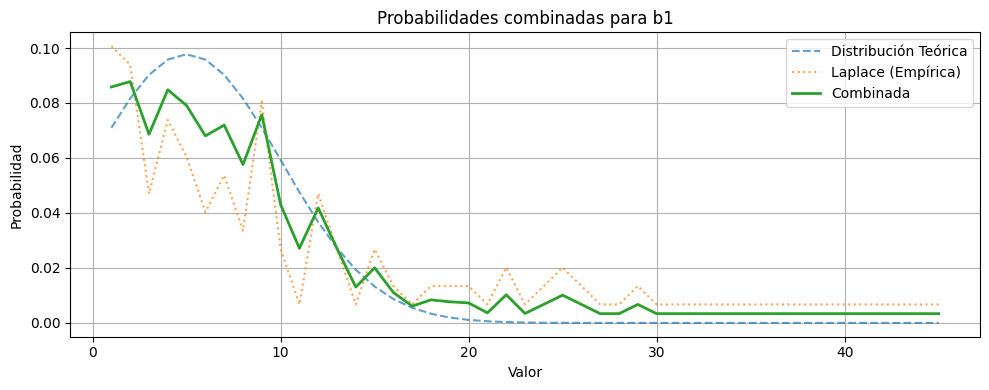

🎯 Siguientes valores más probables para b1:
  2: 0.0878
  1: 0.0858
  4: 0.0848
  5: 0.0791
  9: 0.0758
  7: 0.0720
  3: 0.0686
  6: 0.0680
  8: 0.0576
  10: 0.0431


In [41]:
b1_vals = next_gen_analyze("b1", body_size=104)

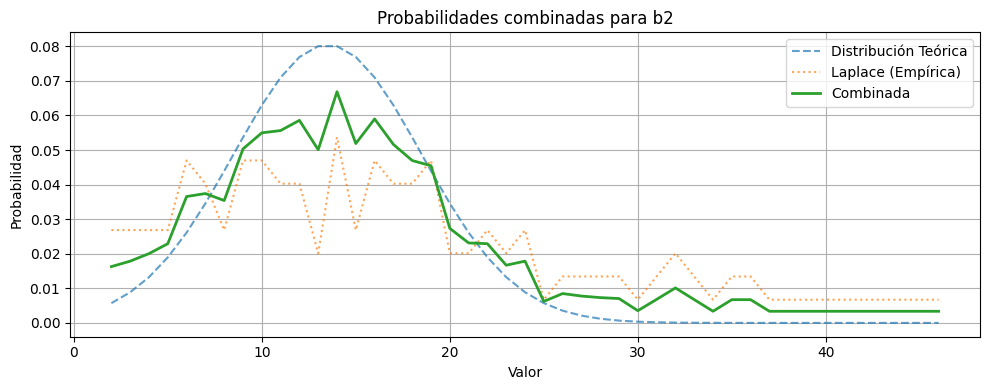

🎯 Siguientes valores más probables para b2:
  14: 0.0669
  16: 0.0590
  12: 0.0586
  11: 0.0556
  10: 0.0550
  15: 0.0519
  17: 0.0516
  9: 0.0503
  13: 0.0501
  18: 0.0470


In [42]:
b2_vals = next_gen_analyze("b2", body_size=104)

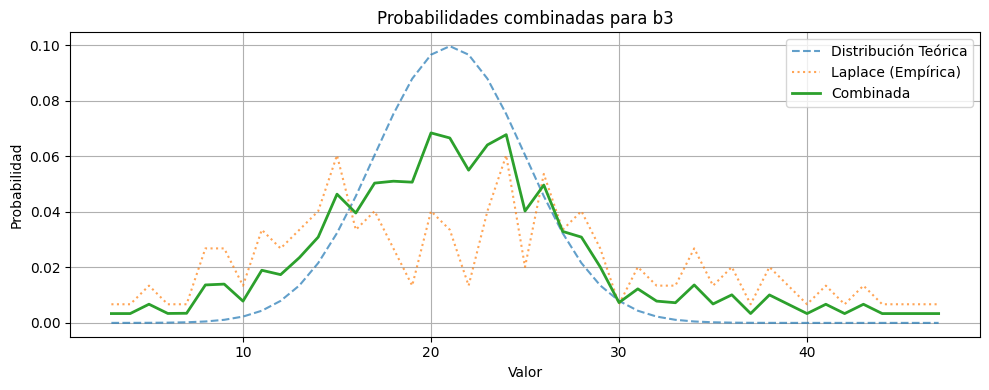

🎯 Siguientes valores más probables para b3:
  20: 0.0685
  24: 0.0678
  21: 0.0666
  23: 0.0641
  22: 0.0550
  18: 0.0511
  19: 0.0507
  17: 0.0504
  26: 0.0497
  15: 0.0464


In [43]:
b3_vals = next_gen_analyze("b3", body_size=104)

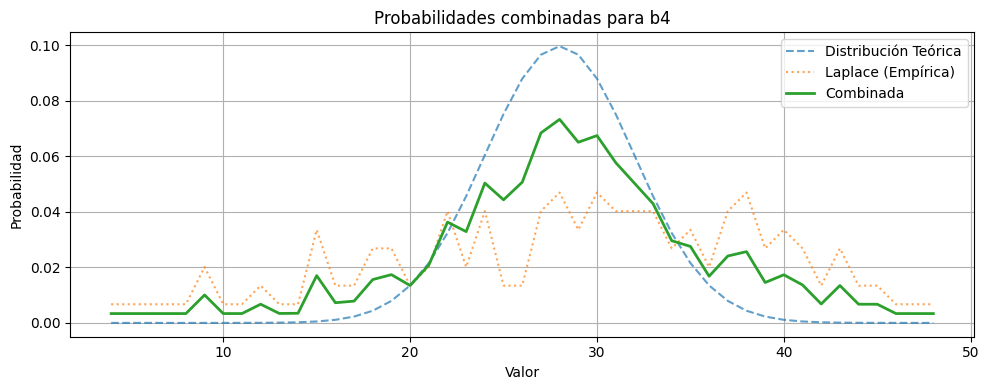

🎯 Siguientes valores más probables para b4:
  28: 0.0734
  27: 0.0685
  30: 0.0675
  29: 0.0651
  31: 0.0578
  26: 0.0507
  24: 0.0504
  32: 0.0504
  25: 0.0444
  33: 0.0430


In [44]:
b4_vals = next_gen_analyze("b4", body_size=104)

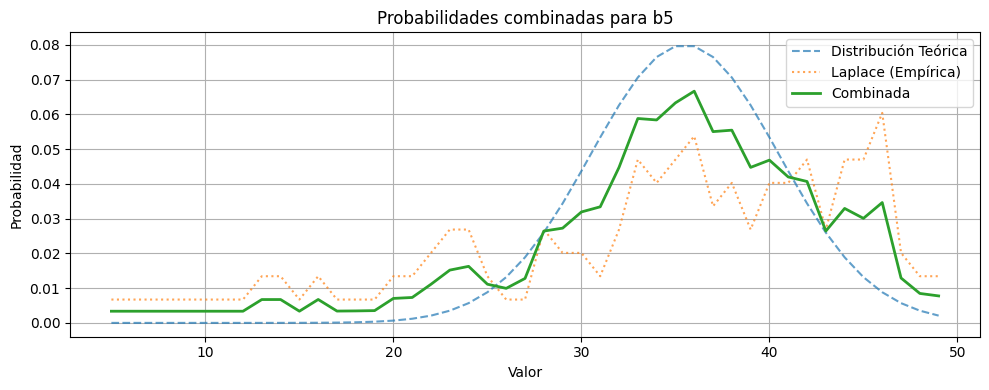

🎯 Siguientes valores más probables para b5:
  36: 0.0666
  35: 0.0633
  33: 0.0588
  34: 0.0584
  38: 0.0554
  37: 0.0550
  40: 0.0468
  32: 0.0447
  39: 0.0447
  41: 0.0420


In [45]:
b5_vals = next_gen_analyze("b5", body_size=104)

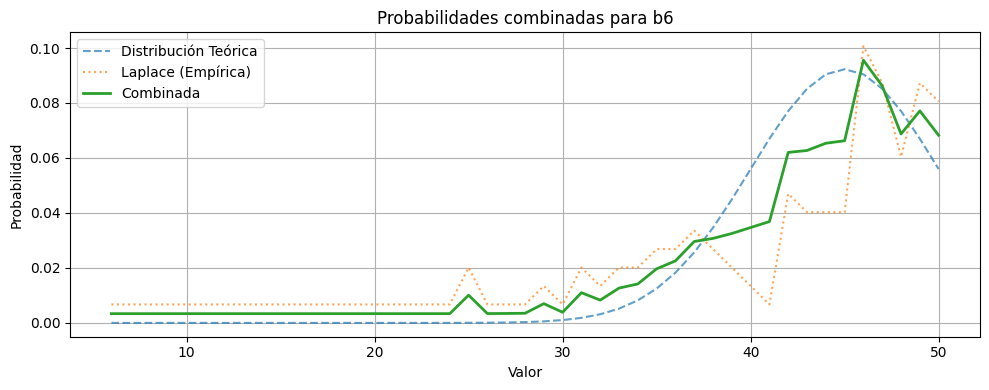

🎯 Siguientes valores más probables para b6:
  46: 0.0956
  47: 0.0862
  49: 0.0771
  48: 0.0687
  50: 0.0683
  45: 0.0663
  44: 0.0654
  43: 0.0627
  42: 0.0620
  41: 0.0369


In [46]:
b6_vals = next_gen_analyze("b6", body_size=104)